In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import random

import numpy as np
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt

from utils.path import PROJECT_ROOT
from transform.augmentation import augmentation_transform

# Set random seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)


In [2]:
def augment_synthetic_dataset(
    csv_path: str,
    img_dir: str,
    save_img_dir: str,
    save_csv_path: str,
    transform,
    aug_per_image: int,
):
    os.makedirs(save_img_dir, exist_ok=True)
    if os.listdir(save_img_dir):
        raise RuntimeError(f"Directory {save_img_dir} is not empty")

    df = pd.read_csv(csv_path)
    augmented_rows = []

    for _, row in df.iterrows():
        img_path = os.path.join(img_dir, row["image"])

        try:
            image = Image.open(img_path).convert("RGB")
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            continue
        image_np = np.array(image)

        for i in range(aug_per_image):
            aug = transform(image=image_np)
            aug_img_np = aug["image"]
            assert aug_img_np.ndim == 3 and aug_img_np.shape[2] == 3

            aug_img = Image.fromarray(aug_img_np)

            aug_name = f"{os.path.splitext(row['image'])[0]}_aug{i+1}.png"
            aug_img.save(os.path.join(save_img_dir, aug_name))

            aug_row = row.to_dict()
            aug_row["image"] = aug_name
            augmented_rows.append(aug_row)

    df_aug = pd.DataFrame(augmented_rows)
    df_aug.to_csv(save_csv_path, index=False)

    print(f"Augmented images saved to: {save_img_dir}")
    print(f"Augmented CSV saved to: {save_csv_path}")
    print(f"Total augmented images: {len(df_aug)}")



BASE_DATA_DIR = f"{PROJECT_ROOT}/dataset/word_nglegena_synthetic_20260130_155231"
AUG_PER_IMAGE = 2

augment_synthetic_dataset(
    csv_path=f"{BASE_DATA_DIR}/label_train.csv",
    img_dir=f"{BASE_DATA_DIR}/image_train",
    save_img_dir=f"{BASE_DATA_DIR}/image_train_aug",
    save_csv_path=f"{BASE_DATA_DIR}/label_train_aug.csv",
    transform=augmentation_transform(prob=1.0, seed=SEED),
    aug_per_image=AUG_PER_IMAGE,
)


Augmented images saved to: C:\Users\adefa\Project\ocr-javanese-script/dataset/word_nglegena_synthetic_20260130_155231/image_train_aug
Augmented CSV saved to: C:\Users\adefa\Project\ocr-javanese-script/dataset/word_nglegena_synthetic_20260130_155231/label_train_aug.csv
Total augmented images: 2000


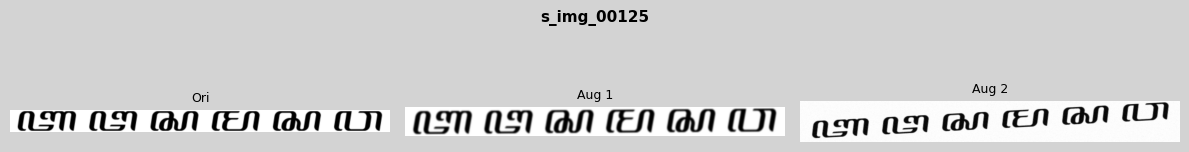

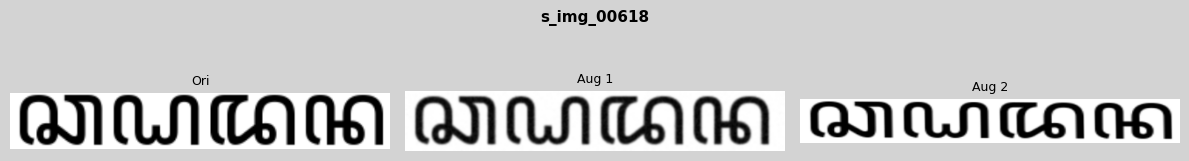

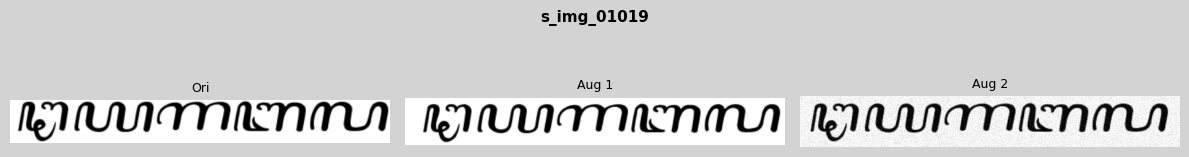

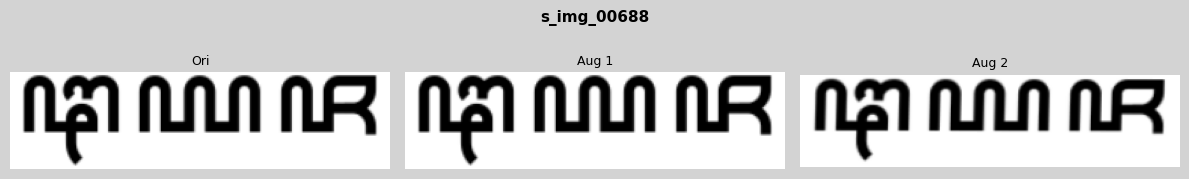

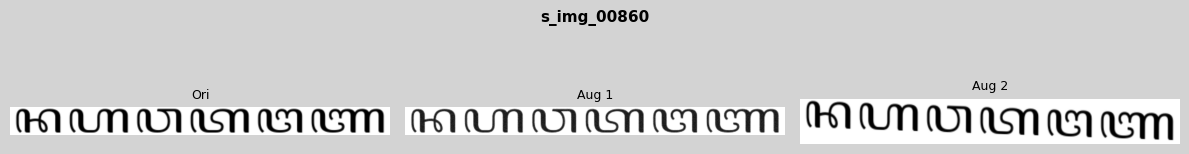

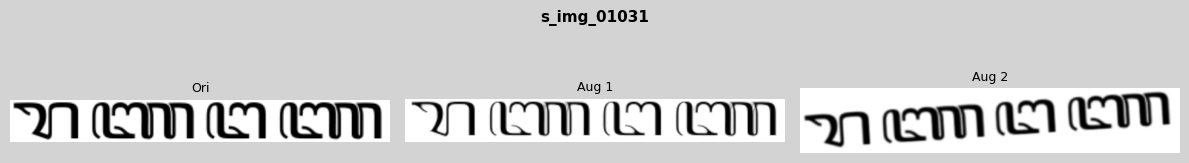

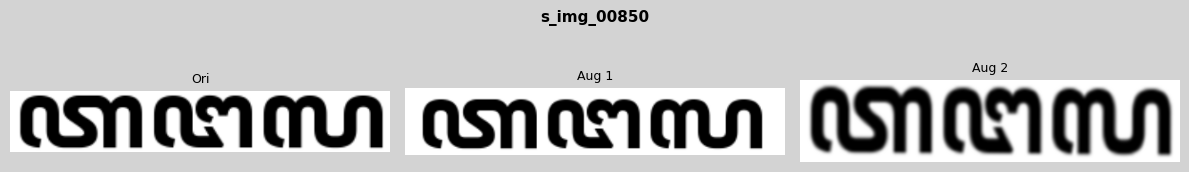

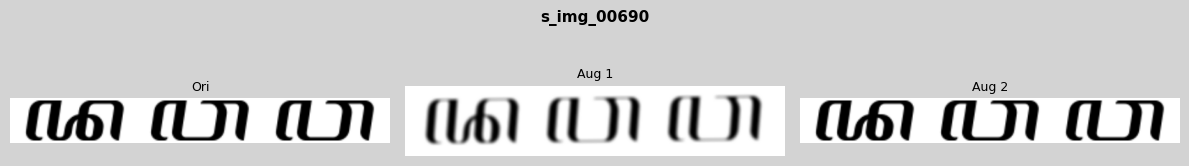

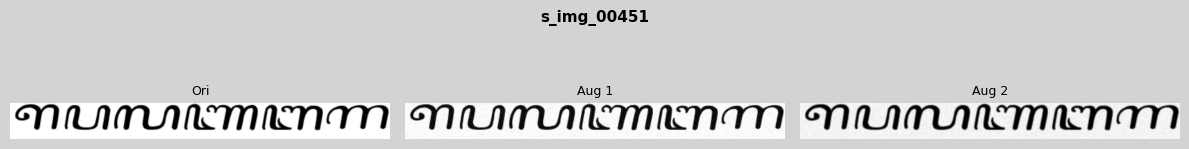

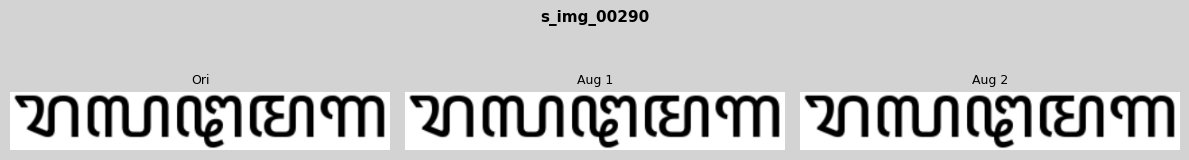

In [3]:
def visualize_augmentations(
    csv_ori,
    dir_ori,
    csv_aug,
    dir_aug,
    n_samples=5,
    max_aug=6,
):
    df_ori = pd.read_csv(csv_ori)
    df_aug = pd.read_csv(csv_aug)

    samples = df_ori.sample(n=min(n_samples, len(df_ori)), random_state=SEED)

    for _, row in samples.iterrows():
        base = row["image"].replace(".png", "")

        imgs = [Image.open(os.path.join(dir_ori, row["image"])).convert("L")]
        titles = ["Ori"]

        aug_rows = df_aug[df_aug["image"].str.startswith(base + "_aug")]
        for i, fname in enumerate(aug_rows["image"][:max_aug], 1):
            imgs.append(Image.open(os.path.join(dir_aug, fname)).convert("L"))
            titles.append(f"Aug {i}")

        fig, axes = plt.subplots(1, len(imgs), figsize=(4 * len(imgs), 2), facecolor="lightgray")
        if len(imgs) == 1:
            axes = [axes]

        for ax, img, title in zip(axes, imgs, titles):
            ax.imshow(img, cmap="gray")
            ax.set_title(title, fontsize=9)
            ax.axis("off")

        plt.suptitle(base, fontsize=11, fontweight="bold")
        plt.tight_layout()
        plt.show()



visualize_augmentations(
    csv_ori=f"{BASE_DATA_DIR}/label_train.csv",
    dir_ori=f"{BASE_DATA_DIR}/image_train",
    csv_aug=f"{BASE_DATA_DIR}/label_train_aug.csv",
    dir_aug=f"{BASE_DATA_DIR}/image_train_aug",
    n_samples=10,
    max_aug=4,
)
